В этой части я собираю пайплайн решения системы распознавания лиц.
1. Детектор по условиям можно было взять готовый. Что я и делаю.
2. Собираю свою уже обученную нейросеть, позволяющую найти ключевые точки лица и выдать их в формате haetmaps.
3. Беру свою обученную систему распознавания лиц на основе предобученной ResNet50 с добавленным ArcFace
4. Собираю пайплайн
5. Делаю простой пользовательский интерфейс

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install facenet-pytorch torchvision opencv-python numpy matplotlib -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

После выполнения предыдущей ячейки (СЕЙЧАС!) перезапустите сеанс (ядро)!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN
from PIL import Image
import os
import torchvision
from torchvision import models
import torch.nn.functional as F
import math
from torchvision import transforms as T

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# Трансформации
from torchvision import transforms as T
transform_kp = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_rec = T.Compose([
    T.Resize((112, 112)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Детектор

In [3]:
from facenet_pytorch import MTCNN
import cv2

mtcnn = MTCNN(keep_all=True, device=device)

def detect_faces(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn.detect(img_rgb)
    return boxes, img_rgb  # возвращаем координаты и RGB‑изображение

## Ключевые точки и выравнивание

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

In [5]:
class HourglassBlock(nn.Module):
    def __init__(self, depth, in_channels, out_channels, pool=nn.MaxPool2d(2, 2), upsample=nn.Upsample(scale_factor=2, mode='nearest')):
        """
        :param depth: глубина рекурсии (количество уровней down/upsampling)
        :param in_channels: количество входных каналов
        :param out_channels: количество выходных каналов
        :param pool: слой для downsampling (например, nn.MaxPool2d или nn.Conv2d)
        :param upsample: слой для upsampling (например, nn.Upsample или nn.ConvTranspose2d)
        """
        super(HourglassBlock, self).__init__()
        self.depth = depth
        self.pool = pool
        self.upsample = upsample

        # bottleneck
        self.bottleneck = ResidualBlock(in_channels, out_channels)

        # Энкодер
        self.encoder = nn.ModuleList([
            ResidualBlock(in_channels, out_channels) for _ in range(depth)
        ])

        # Декодер
        self.decoder = nn.ModuleList([
            ResidualBlock(in_channels, out_channels) for _ in range(depth)
        ])

        # Рекурсивный Hourglass
        if depth > 1:
            self.hourglass = HourglassBlock(depth - 1, in_channels, out_channels, pool, upsample)

    def forward(self, x):
        # Энкодер: downsampling + ResidualBlock
        encoded = []
        for i, encoder_block in enumerate(self.encoder):
            x = encoder_block(x)
            encoded.append(x.clone())  # Сохраняем копию для skip-connection
            x = self.pool(x)  # Downsampling

        # Нижний уровень (bottleneck)
        x = self.bottleneck(x)

        # Если глубина > 1, применяем рекурсивный Hourglass
        if self.depth > 1:
            x = self.hourglass(x)

        # Декодер: upsampling + ResidualBlock + skip-connection
        for i in range(self.depth):
            x = self.upsample(x)  # Upsampling

            # Проверка совместимости skip-connection по каналам
            skip = encoded[-(i + 1)]
            if skip.shape[1]!= x.shape[1]:  # Если число каналов не совпадает
                # Преобразуем skip-connection к нужному числу каналов
                skip = nn.Conv2d(skip.shape[1], x.shape[1], 1)(skip)

            # Проверка совместимости по пространственному размеру
            if skip.shape[2:] != x.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:], mode='nearest')

            x = x + skip  # Skip-connection
            x = self.decoder[i](x)  # ResidualBlock

        return x


In [6]:
class StackedHourglass(nn.Module):
    def __init__(self, num_stacks=2, in_channels=256, num_joints=5):
        super(StackedHourglass, self).__init__()
        self.num_stacks = num_stacks
        self.hourglass_blocks = nn.ModuleList([
            HourglassBlock(depth=2, in_channels=in_channels, out_channels=in_channels)
            for _ in range(num_stacks)
        ])

        # Линейный слой для предсказания heatmaps на выходе каждого стека
        self.conv_out = nn.Conv2d(in_channels, num_joints, 1)

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.001)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        outputs = []
        for i in range(self.num_stacks):
            x = self.hourglass_blocks[i](x)
            # Увеличиваем выход Hourglass до 256x256
            x_up = F.interpolate(x, size=(256, 256), mode='bilinear', align_corners=False)
            pred = self.conv_out(x_up)  # [B, num_joints, 256, 256]
            outputs.append(pred)  # Промежуточные предсказания (heatmaps)
        return outputs  # Список из num_stacks heatmaps

In [7]:
class InitialConv(nn.Module):
    def __init__(self, in_channels=3, out_channels=256):
        super(InitialConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
            ResidualBlock(64, 64),
            nn.Conv2d(64, out_channels, 1)
        )

    def forward(self, x):
        return self.conv(x)

In [8]:
class FullStackedHourglass(nn.Module):
    def __init__(self, num_stacks=2, num_joints=5):
        super(FullStackedHourglass, self).__init__()
        self.initial_conv = InitialConv(in_channels=3, out_channels=256)
        self.stacked_hourglass = StackedHourglass(num_stacks, in_channels=256, num_joints=num_joints)

    def forward(self, x):
        x = self.initial_conv(x)  # Приводим к 256 каналам
        return self.stacked_hourglass(x)  # Получаем список heatmaps

In [9]:
# Модель ключевых точек (stacked hourglass)
model_kp = FullStackedHourglass(num_stacks=2, num_joints=5)
model_kp.load_state_dict(torch.load('/content/drive/MyDrive/DLS1/stacked_hourglass.pth', map_location=device))
model_kp.eval().to(device)

FullStackedHourglass(
  (initial_conv): InitialConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): ResidualBlock(
        (skip): Identity()
        (conv1): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (5): Conv2d(64, 256, kernel_size=(1,

In [10]:
# Получение точек
def get_keypoints(image_tensor):
    with torch.no_grad():
        heatmaps = model_kp(image_tensor.unsqueeze(0))
    keypoints = []
    for i in range(heatmaps.shape[1]):
        hmap = heatmaps[0, i].cpu().numpy()
        y, x = np.unravel_index(np.argmax(hmap), hmap.shape)
        keypoints.append((x, y))
    return np.array(keypoints)

In [11]:
# Целевые точки (эталон)
DST_POINTS = np.float32([
    [80, 80],   # левый глаз
    [176, 80],  # правый глаз
    [128, 140]  # нос
])

In [12]:
def align_face(pil_image, src_points, dst_points):
    """
    Выравнивание лица по эталонным точкам.
    :param pil_image: PIL.Image
    :param src_points: (5, 2) — ключевые точки на входном изображении
    :param dst_points: (5, 2) — эталонные точки
    :return: PIL.Image выровненное изображение
    """
    img = np.array(pil_image)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Получаем аффинное преобразование
    M = cv2.getAffineTransform(src_points[:3], dst_points[:3])  # используем 3 точки (глаза + нос)
    aligned_bgr = cv2.warpAffine(img_bgr, M, (256, 256))
    aligned_rgb = cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB)

    return Image.fromarray(aligned_rgb)

## Распознавание (эмбеддинги)

In [13]:
# Модель распознавания (ResNet + ArcFace)
class ResNet50ArcFace(nn.Module):
    def __init__(self, num_classes, s=30.0, m=0.5):
        super().__init__()
        self.resnet = models.resnet50(pretrained=True)
        # Заменяем fc на ArcFace
        self.fc = ArcFace(self.resnet.fc.in_features, num_classes, s, m)

    def forward_features(self, x):
        # Пропускаем через все слои до fc
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x, labels=None):
        features = self.forward_features(x)
        if labels is not None:
            return self.fc(features, labels)  # Для обучения
        else:
            return features  # Для инференса

class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s  # масштаб
        self.m = m  # угол маржи

        # Веса слоя (будут нормализованы при вычислении)
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        # Предварительно вычисляем константы для ускорения
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)  # порог для условия
        self.mm = math.sin(math.pi - m) * m  # коррекция для малых углов

    def forward(self, input, label=None):
        # Нормализация входных признаков
        x = nn.functional.normalize(input)
        # Нормализация весов
        W = nn.functional.normalize(self.weight)
        # Косинусное сходство (базовая матрица сходств)
        cosine = torch.mm(x, W.t())

        # Если мы в режиме инференса ИЛИ label не передан — возвращаем просто масштабированное косинусное сходство
        if not self.training or label is None:
            return cosine * self.s

        # Режим обучения: применяем ArcFace с маржой
        # Вычисление sin(θ) через тождество
        sine = torch.sqrt((1.0 - torch.pow(cosine, 2)).clamp(0, 1))
        # cos(θ + m) = cosθ·cosm − sinθ·sinm
        phi = cosine * self.cos_m - sine * self.sin_m

        # Коррекция для углов > π − m (чтобы градиенты были стабильны)
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        # One-hot для целевых классов
        one_hot = torch.zeros(cosine.size(), device=cosine.device)
        one_hot.scatter_(1, label.view(-1, 1), 1)

        # Для целевого класса используем cos(θ + m), для остальных — cos(θ)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s  # масштабирование

        return output

num_classes = 556
model_rec = ResNet50ArcFace(num_classes, s=30.0, m=0.5)
model_rec.fc = ArcFace(model_rec.fc.in_features, num_classes, s=30.0, m=0.5)
model_rec.load_state_dict(torch.load('/content/drive/MyDrive/DLS1/resnet_arcface.pth', map_location=device))
model_rec.eval().to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


ResNet50ArcFace(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

Трансформации:

In [14]:
# Для модели предсказания ключевых точек (на входе 256×256, нормализация как в обучении)
transform_kp = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Для модели распознавания лиц (на входе 224×224, нормализация как на валидации)
transform_rec = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Вот эта функция без обрезки по Bbox

In [15]:
def get_embedding(image_rgb):
    # Обнаружение лиц
    boxes, _ = mtcnn.detect(image_rgb)
    if boxes is None or len(boxes) == 0:
        return None

    # Берём первое найденное лицо
    box = boxes[0]

    # Получаем ключевые точки (5 точек: глаза, нос, уголки рта)
    with torch.no_grad():
        # Преобразуем изображение в тензор для модели ключевых точек
        img_tensor = transform_kp(Image.fromarray(image_rgb)).unsqueeze(0).to(device)
        heatmaps = model_kp(img_tensor)
        # Берём последний стек heatmaps
        heatmap = heatmaps[-1][0].cpu().numpy()  # (5, 256, 256)

    keypoints = []
    for i in range(heatmap.shape[0]):  # 5 точек
        hmap = heatmap[i]
        y, x = np.unravel_index(np.argmax(hmap), hmap.shape)
        keypoints.append([x, y])
    src_points = np.float32(keypoints)

    # Выравниваем лицо по эталонным точкам
    aligned_rgb = align_face(Image.fromarray(image_rgb), src_points, DST_POINTS)

    # Преобразуем в тензор для модели распознавания
    tensor = transform_rec(aligned_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model_rec(tensor)
        embedding = F.normalize(embedding, p=2, dim=1)
    return embedding.cpu().numpy().flatten()

А вот эта функция с обрезкой по BBox

In [16]:
'''
def get_embedding2(image_rgb, return_intermediates=False):
    #  Обнаружение лица через MTCNN
    boxes, _ = mtcnn.detect(image_rgb)
    if boxes is None or len(boxes) == 0:
        return (None, None, None) if return_intermediates else None

    box = boxes[0]

    # Преобразуем в PIL.Image
    pil_image = Image.fromarray(image_rgb)
    w_orig, h_orig = pil_image.size


    # Обрезаем до квадратного bbox
    x1, y1, x2, y2 = box
    width, height = x2 - x1, y2 - y1
    side = min(width, height)
    center_x, center_y = x1 + width / 2, y1 + height / 2
    x1_square, y1_square = center_x - side / 2, center_y - side / 2
    x2_square, y2_square = center_x + side / 2, center_y + side / 2


    padding = 0
    x1_crop = max(0, int(x1_square - padding))
    y1_crop = max(0, int(y1_square - padding))
    x2_crop = min(w_orig, int(x2_square + padding))
    y2_crop = min(h_orig, int(y2_square + padding))


    cropped_img = pil_image.crop((x1_crop, y1_crop, x2_crop, y2_crop))


    # Ресайз до 256×256 для модели ключевых точек
    resized_img = cropped_img.resize((256, 256), Image.LANCZOS)


    # Предсказываем ключевые точки
    with torch.no_grad():
        img_tensor = transform_kp(resized_img).unsqueeze(0).to(device)  # [1, 3, 256, 256]
        heatmaps = model_kp(img_tensor)  # list из выходов модели
        heatmap = heatmaps[-1][0].cpu().numpy()  # последний выход, [5, 256, 256]


    keypoints = []
    for i in range(heatmap.shape[0]):  # для каждой из 5 точек
        hmap = heatmap[i]
        y, x = np.unravel_index(np.argmax(hmap), hmap.shape)
        keypoints.append([x, y])
    src_points = np.float32(keypoints)  # [5, 2]


    #  Выравнивание по 3 точкам (глаза, нос)
    aligned_rgb = align_face(resized_img, src_points, DST_POINTS)  # DST_POINTS — эталон


    # Получаем эмбеддинг (после выравнивания, размер 224×224)
    tensor = transform_rec(aligned_rgb).unsqueeze(0).to(device)  # [1, 3, 224, 224]
    with torch.no_grad():
        embedding = model_rec(tensor)  # модель распознавания
        embedding = F.normalize(embedding, p=2, dim=1)  # L2-нормализация


    # Возвращаем результат
    if return_intermediates:
        return (
            embedding.cpu().numpy().flatten(),  # эмбеддинг
            np.array(resized_img),             # обрезанное 256×256
            np.array(aligned_rgb)                  # выровненное 256×256
        )
    else:
        return embedding.cpu().numpy().flatten()
  '''

In [29]:
def get_embedding2(image_rgb, return_intermediates=False):
    # Обнаружение лица через MTCNN
    boxes, _ = mtcnn.detect(image_rgb)
    if boxes is None or len(boxes) == 0:
        return (None, None, None) if return_intermediates else None

    box = boxes[0]

    # Преобразуем в PIL.Image
    pil_image = Image.fromarray(image_rgb)
    w_orig, h_orig = pil_image.size

    # Обрезаем до квадратного bbox (как было в исходниках для обучения модели)
    x1, y1, x2, y2 = box
    width, height = x2 - x1, y2 - y1
    side = min(width, height)
    center_x, center_y = x1 + width / 2, y1 + height / 2
    x1_square, y1_square = center_x - side / 2, center_y - side / 2
    x2_square, y2_square = center_x + side / 2, center_y + side / 2

    padding = 0
    x1_crop = max(0, int(x1_square - padding))
    y1_crop = max(0, int(y1_square - padding))
    x2_crop = min(w_orig, int(x2_square + padding))
    y2_crop = min(h_orig, int(y2_square + padding))

    cropped_img = pil_image.crop((x1_crop, y1_crop, x2_crop, y2_crop))

    # Ресайз до 256×256
    resized_img = cropped_img.resize((256, 256), Image.LANCZOS)


    # Ключевые точки на обрезанном/ресайзенном изображении
    with torch.no_grad():
        img_tensor = transform_kp(resized_img).unsqueeze(0).to(device)
        heatmaps = model_kp(img_tensor)
        heatmap = heatmaps[-1][0].cpu().numpy()  # (5, 256, 256)


    keypoints = []
    for i in range(heatmap.shape[0]):
        hmap = heatmap[i]
        y, x = np.unravel_index(np.argmax(hmap), hmap.shape)
        keypoints.append([x, y])
    src_points = np.float32(keypoints)

    # Выравнивание
    aligned_rgb = align_face(resized_img, src_points, DST_POINTS)

    # Эмбеддинг
    tensor = transform_rec(aligned_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = model_rec(tensor)
        embedding = F.normalize(embedding, p=2, dim=1)


    if return_intermediates:
        # Возвращаем: эмбеддинг, обрезанное, выровненное
        return (
            embedding.cpu().numpy().flatten(),
            np.array(resized_img),      # обрезанное (256×256)
            np.array(aligned_rgb)           # выровненное
        )
    else:
        return embedding.cpu().numpy().flatten()

Для каждого выровненного лица происходит:
- обрезка, получение ключевых точек, выравнивание
- препроцессинг (Resize, ToTensor, Normalize);
- forward pass через модель → получаем эмбеддинг (вектор, например, размерности 512).
- нормализация эмбеддингов (L2‑нормализация)

## Оценка (косинусное сходство)

Сравнение эмбеддингов: метрика косинусного сходства
Задача: оценить, насколько похожи два лица.
Метрика: косинусное сходство:

Первая функция заводит пайплайн без обрезки по Bbox
(я сначала ошиблась и не установила обрезку, а потом решила оставить для сравнения)

In [30]:
# Функция сравнения двух изображений
def compare_faces(img_path1, img_path2):
    # Загрузка изображений
    img1 = cv2.imread(img_path1)
    img2 = cv2.imread(img_path2)

    if img1 is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение: {img_path1}")
    if img2 is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение: {img_path2}")


    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


    # Получение эмбеддингов
    emb1 = get_embedding(img1_rgb)
    emb2 = get_embedding(img2_rgb)

    if emb1 is None:
        raise ValueError(f"На первом изображении не найдено лиц: {img_path1}")
    if emb2 is None:
        raise ValueError(f"На втором изображении не найдено лиц: {img_path2}")


    # Косинусное сходство
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

    return similarity

А эта функция заводит пайплайн с обрезкой по Bbox

In [31]:
# Функция сравнения двух изображений
def compare_faces2(img_path1, img_path2):
    # Загрузка изображений
    img1 = cv2.imread(img_path1)
    img2 = cv2.imread(img_path2)

    if img1 is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение: {img_path1}")
    if img2 is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение: {img_path2}")


    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


    # Получение эмбеддингов
    emb1 = get_embedding2(img1_rgb)
    emb2 = get_embedding2(img2_rgb)

    if emb1 is None:
        raise ValueError(f"На первом изображении не найдено лиц: {img_path1}")
    if emb2 is None:
        raise ValueError(f"На втором изображении не найдено лиц: {img_path2}")


    # Косинусное сходство
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

    return similarity

Выводы тоже будут две разные функции, одн адля пайплайна без обрезки, одна для пайплайна с обрезкой. Наглядно будет сравнить

Первая без обрезки.

In [32]:
# Визуализация результатов
def show_comparison(img_path1, img_path2, similarity):
    img1 = cv2.imread(img_path1)
    img2 = cv2.imread(img_path2)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img1_rgb)
    plt.title("Изображение 1")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2_rgb)
    plt.title("Изображение 2")
    plt.axis("off")

    plt.suptitle(f"Косинусное сходство: {similarity:.4f}", fontsize=16)
    plt.show()

In [33]:
def show_comparison2(img_path1, img_path2, similarity):
    # Загружаем изображения
    img1 = cv2.imread(img_path1)
    img2 = cv2.imread(img_path2)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


    # Получаем промежуточные кадры и эмбеддинги
    emb1, cropped1, aligned1 = get_embedding2(img1_rgb, return_intermediates=True)
    emb2, cropped2, aligned2 = get_embedding2(img2_rgb, return_intermediates=True)


    if emb1 is None or emb2 is None:
        print("Лицо не обнаружено на одном из изображений!")
        return

    # Фигура: пайплайн для первого изображения (3 колонки)
    plt.figure(figsize=(18, 6))


    plt.subplot(2, 3, 1)
    plt.imshow(img1_rgb)
    plt.title("1. Исходное изображение", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(cropped1)
    plt.title("2. Обрезанное лицо (256×256)", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(aligned1)
    plt.title("3. Выровненное лицо", fontsize=12)
    plt.axis("off")

    # Пайплайн для второго изображения (3 колонки)
    plt.subplot(2, 3, 4)
    plt.imshow(img2_rgb)
    plt.title("4. Исходное изображение", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(cropped2)
    plt.title("5. Обрезанное лицо (256×256)", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(aligned2)
    plt.title("6. Выровненное лицо", fontsize=12)
    plt.axis("off")

    # Общий заголовок с сходством
    plt.suptitle(f"Косинусное сходство: {similarity:.4f}", fontsize=16, y=0.98)
    plt.show()

## Пользовательский интерфейс

- Первая функция задает интерфейс для пайплайна без обрезки (ошибочное решение)
- Вторая для пайплайна с обрезкой (верное решение задачи)

In [34]:
# Интерфейс для пользователя (запрос фото и вывод результата)
def run_comparison():
    print("Загрузите два изображения для сравнения.")

    # Загружаем
    from google.colab import files
    uploaded = files.upload()

    if len(uploaded) < 2:
        print("Пожалуйста, загрузите ДВА изображения.")
        return

    # Берём первые два загруженных файла
    img_files = list(uploaded.keys())
    img1_path = img_files[0]
    img2_path = img_files[1]

    try:
        similarity = compare_faces(img1_path, img2_path)
        print(f"\n Результат:")
        print(f"Косинусное сходство между лицами: {similarity:.4f}")

        # Визуализация
        show_comparison(img1_path, img2_path, similarity)

        # Интерпретация результата
        if similarity > 0.7:
            print(" Лица, вероятно, принадлежат одному человеку.")
        elif similarity > 0.5:
            print(" Неоднозначно: сходство на границе.")
        else:
            print(" Лица, вероятно, принадлежат разным людям.")

    except Exception as e:
        print(f"Ошибка: {e}")


In [35]:
# Интерфейс для пользователя (запрос фото и вывод результата)
def run_comparison2():
    print("Загрузите два изображения для сравнения.")

    # Загружаем
    from google.colab import files
    uploaded = files.upload()

    if len(uploaded) < 2:
        print("Пожалуйста, загрузите ДВА изображения.")
        return

    # Берём первые два загруженных файла
    img_files = list(uploaded.keys())
    img1_path = img_files[0]
    img2_path = img_files[1]

    try:
        similarity = compare_faces2(img1_path, img2_path)
        print(f"\n Результат:")
        print(f"Косинусное сходство между лицами: {similarity:.4f}")

        # Визуализация
        show_comparison2(img1_path, img2_path, similarity)

        # Интерпретация результата
        if similarity > 0.7:
            print(" Лица, вероятно, принадлежат одному человеку.")
        elif similarity > 0.5:
            print(" Неоднозначно: сходство на границе.")
        else:
            print(" Лица, вероятно, принадлежат разным людям.")

    except Exception as e:
        print(f"Ошибка: {e}")


## Работа пайплайна (сначала с обрезкой)

Подготовить 3 изображения:

img1.jpg — человек A, ракурс 1;

img2.jpg — человек A, ракурс 2;

img3.jpg — человек B.

Загрузите два изображения для сравнения.


Saving Queen-1.webp to Queen-1 (2).webp
Saving Queen-2.webp to Queen-2 (2).webp

 Результат:
Косинусное сходство между лицами: 0.9991


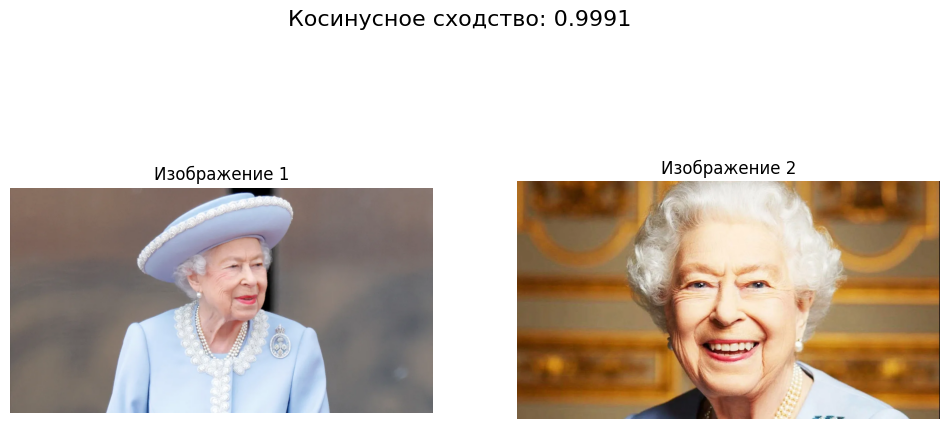

 Лица, вероятно, принадлежат одному человеку.


In [36]:
# Запуск системы
if __name__ == "__main__":
    run_comparison()

Загрузите два изображения для сравнения.


Saving Queen-1.webp to Queen-1 (3).webp
Saving Queen-2.webp to Queen-2 (3).webp

 Результат:
Косинусное сходство между лицами: 0.4068


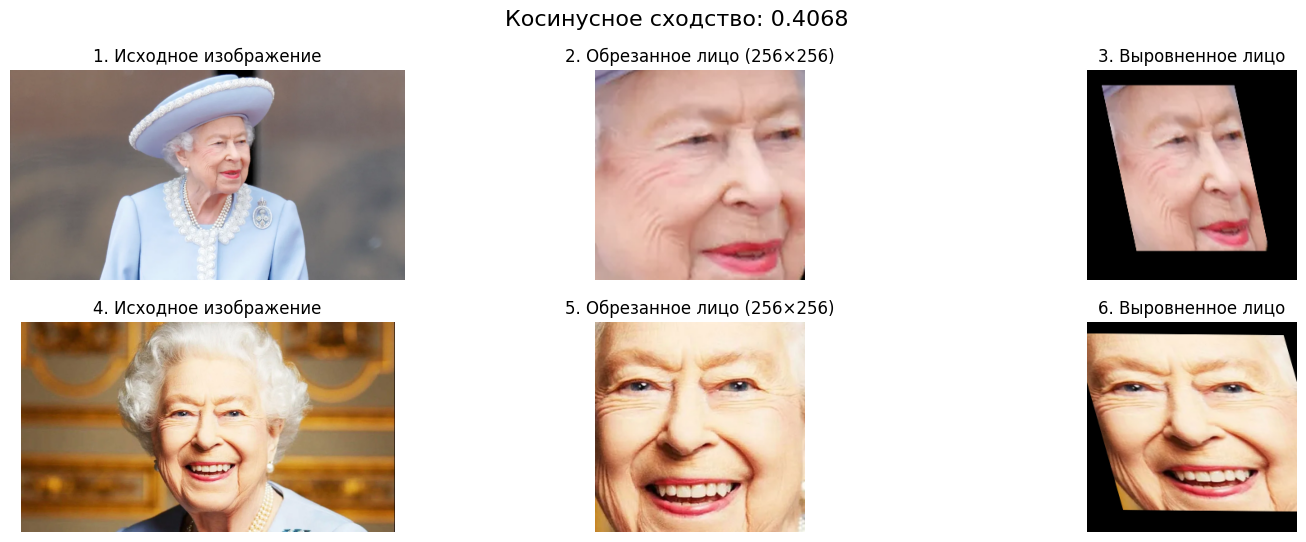

 Лица, вероятно, принадлежат разным людям.


In [37]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Загрузите два изображения для сравнения.


Saving Sadovn-1.webp to Sadovn-1 (2).webp
Saving Sadovn-2.webp to Sadovn-2.webp

 Результат:
Косинусное сходство между лицами: 0.9985


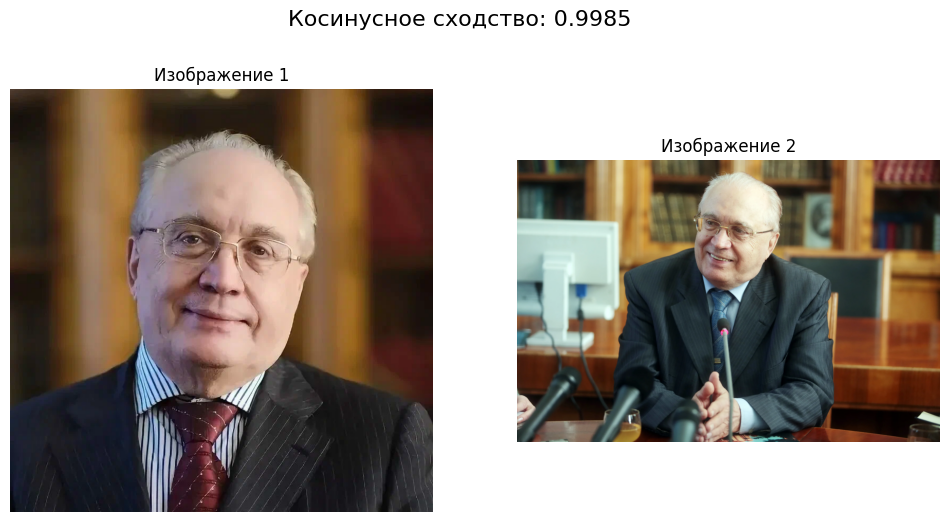

 Лица, вероятно, принадлежат одному человеку.


In [38]:
# Запуск системы
if __name__ == "__main__":
    run_comparison()

Загрузите два изображения для сравнения.


Saving Sadovn-1.webp to Sadovn-1 (3).webp
Saving Sadovn-2.webp to Sadovn-2 (1).webp

 Результат:
Косинусное сходство между лицами: 0.7083


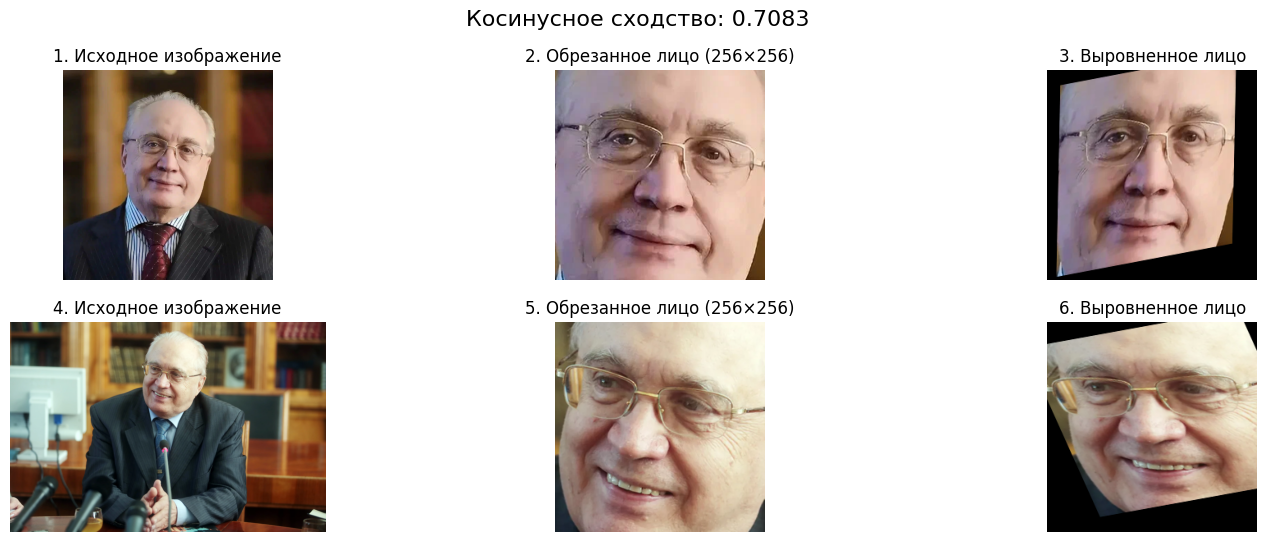

 Лица, вероятно, принадлежат одному человеку.


In [39]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Загрузите два изображения для сравнения.


Saving Queen-2.webp to Queen-2 (5).webp
Saving Sadovn-1.webp to Sadovn-1 (5).webp

 Результат:
Косинусное сходство между лицами: 0.9991


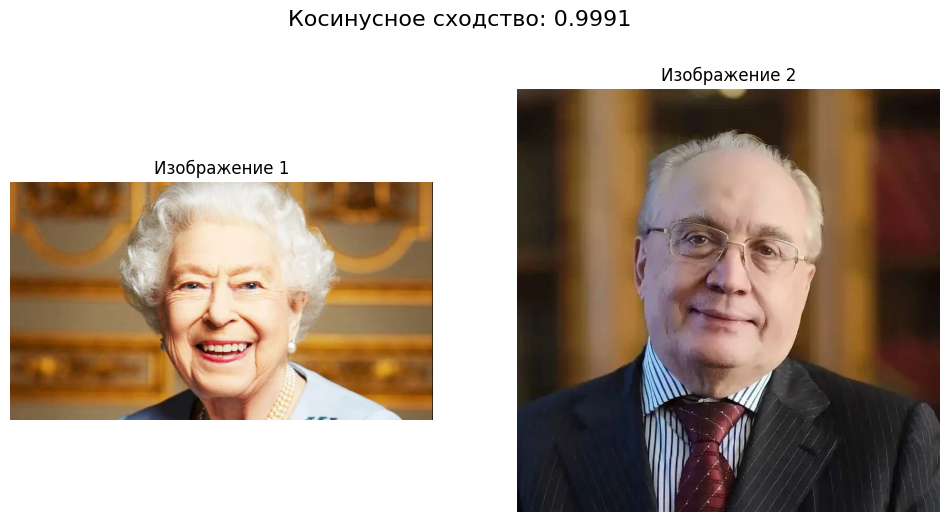

 Лица, вероятно, принадлежат одному человеку.


In [ ]:
# Запуск системы
if __name__ == "__main__":
    run_comparison()

Загрузите два изображения для сравнения.


Saving Queen-2.webp to Queen-2 (4).webp
Saving Sadovn-1.webp to Sadovn-1 (4).webp

 Результат:
Косинусное сходство между лицами: 0.4024


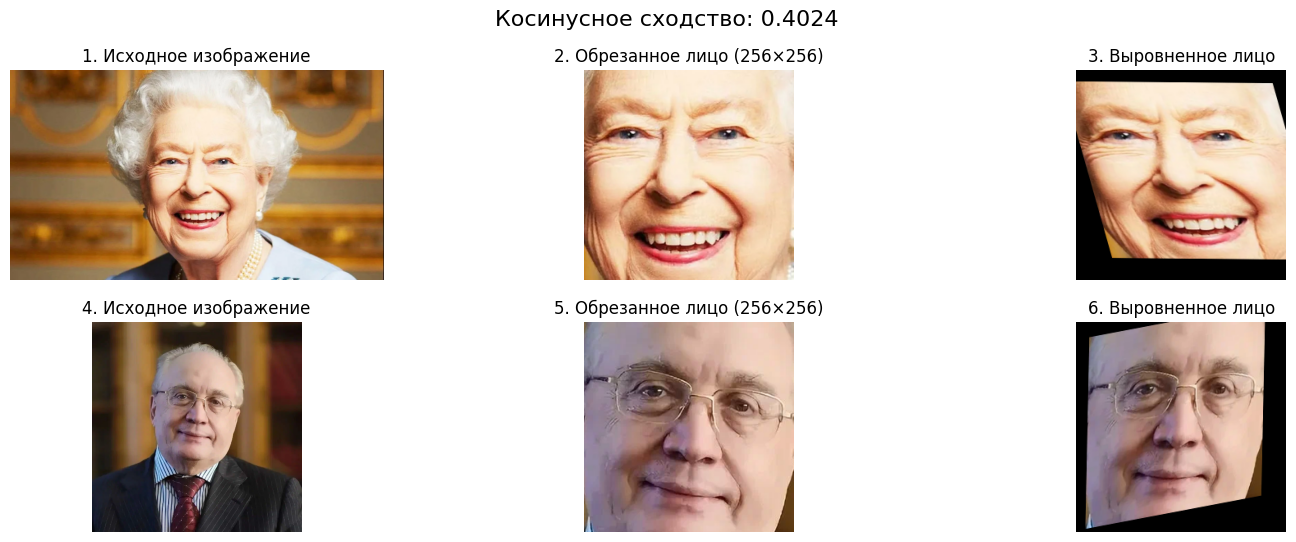

 Лица, вероятно, принадлежат разным людям.


In [40]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Загрузите два изображения для сравнения.


Saving Zemfira-1.webp to Zemfira-1.webp
Saving Zemfira-2.webp to Zemfira-2.webp

 Результат:
Косинусное сходство между лицами: 0.9662


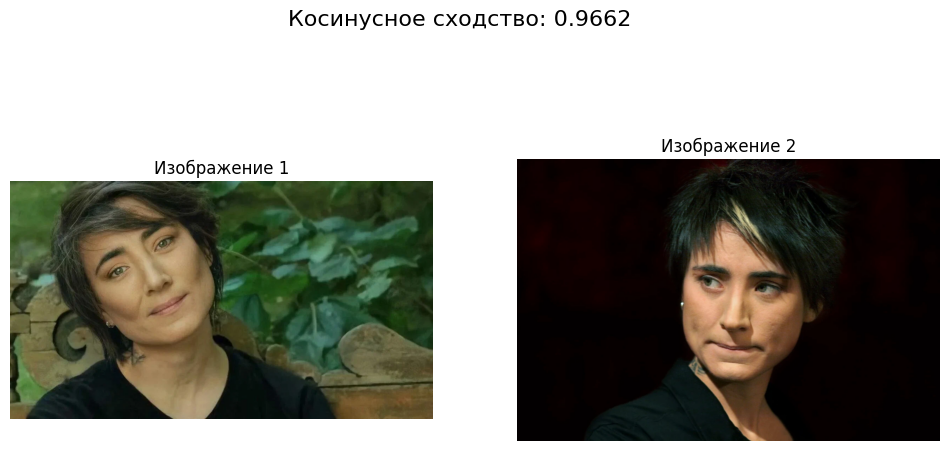

 Лица, вероятно, принадлежат одному человеку.


In [42]:
# Запуск системы
if __name__ == "__main__":
    run_comparison()

Загрузите два изображения для сравнения.


Saving Zemfira-1.webp to Zemfira-1 (1).webp
Saving Zemfira-2.webp to Zemfira-2 (1).webp

 Результат:
Косинусное сходство между лицами: 0.5943


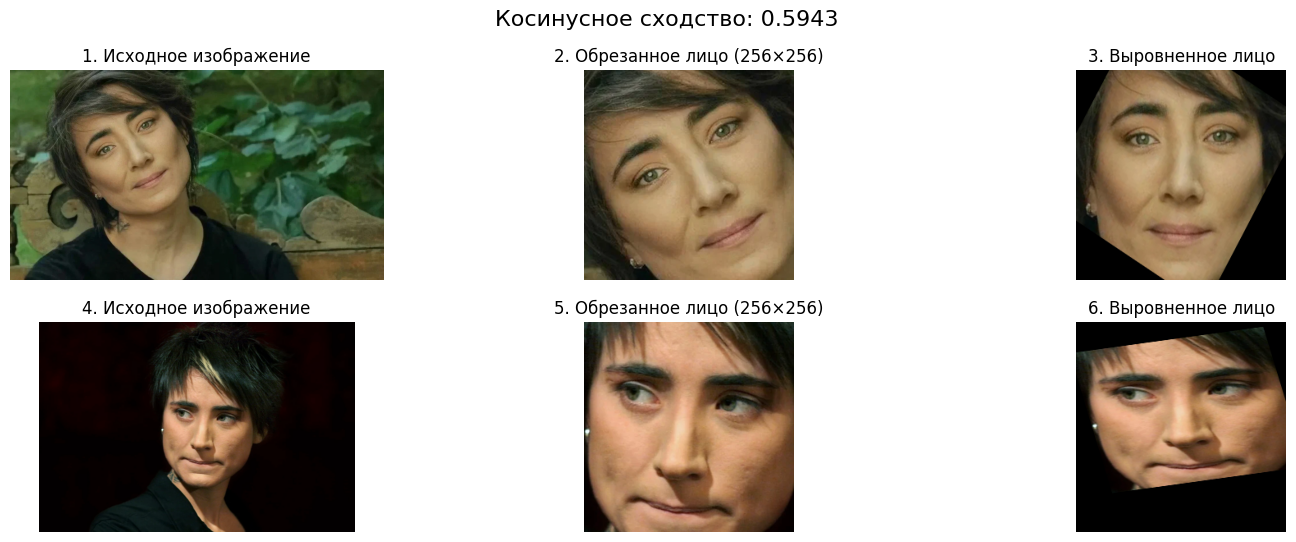

 Неоднозначно: сходство на границе.


In [43]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

С Земфирой пайпланчику тяжело. Ну, мне тоже тяжело, если честно.

Загрузите два изображения для сравнения.


Saving Picture-1.png to Picture-1.png
Saving Picture-2.png to Picture-2.png

 Результат:
Косинусное сходство между лицами: 0.9991


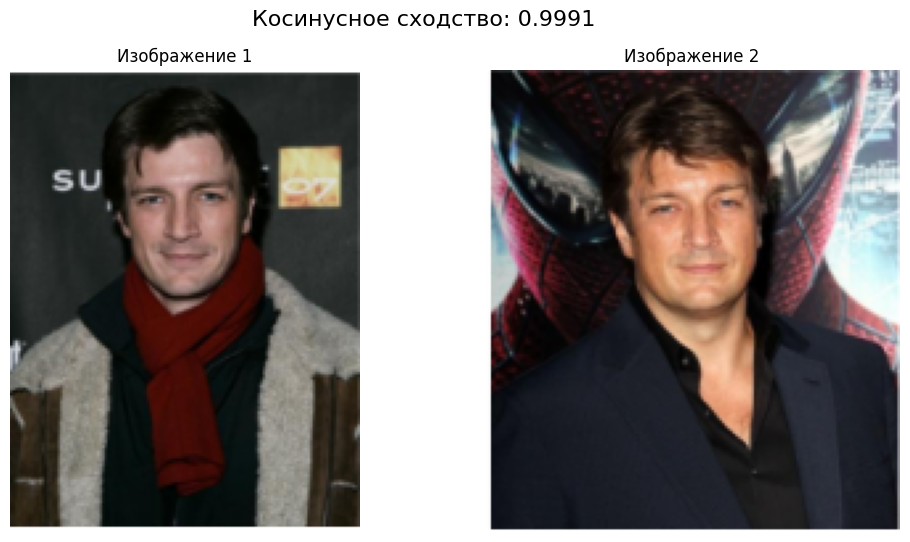

 Лица, вероятно, принадлежат одному человеку.


In [44]:
# Запуск системы
if __name__ == "__main__":
    run_comparison()

Загрузите два изображения для сравнения.


Saving Picture-1.png to Picture-1 (1).png
Saving Picture-2.png to Picture-2 (1).png

 Результат:
Косинусное сходство между лицами: 0.4878


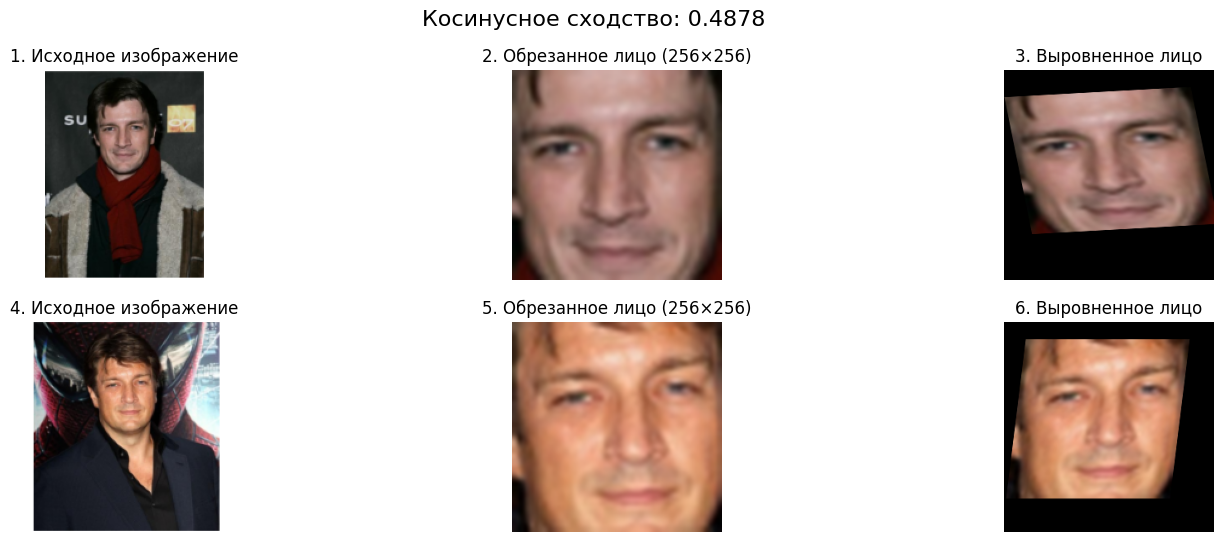

 Лица, вероятно, принадлежат разным людям.


In [45]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Удивительно, однако. Не могу объяснить и предположить, что не так с системой. Наверное, модель распознавания лиц не слишком хорошо научилась. Но, что радует,обрезанные лица она хотя бы между собой не путает.

Загрузите два изображения для сравнения.


Saving Queen-1.webp to Queen-1 (4).webp
Saving Sadovn-1.jpg to Sadovn-1.jpg

 Результат:
Косинусное сходство между лицами: 0.9988


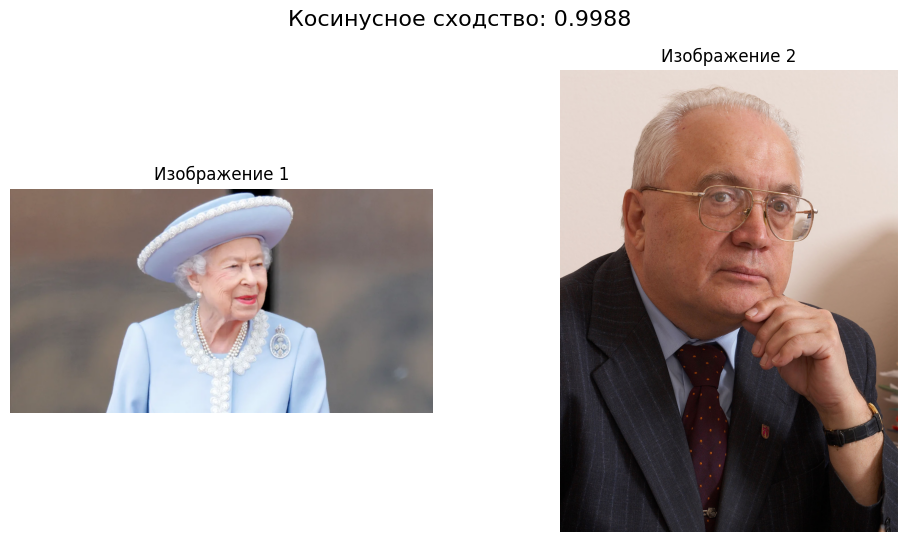

 Лица, вероятно, принадлежат одному человеку.


In [46]:
# Запуск системы
if __name__ == "__main__":
    run_comparison()

Загрузите два изображения для сравнения.


Saving Queen-1.webp to Queen-1 (5).webp
Saving Sadovn-1.jpg to Sadovn-1 (1).jpg

 Результат:
Косинусное сходство между лицами: 0.2868


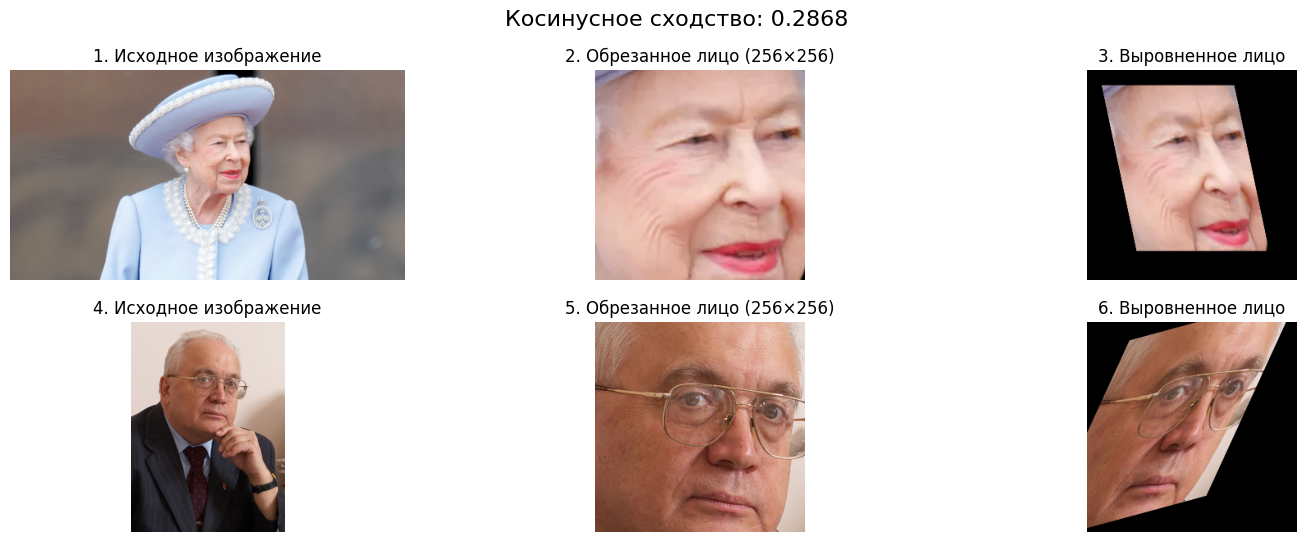

 Лица, вероятно, принадлежат разным людям.


In [47]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Однозначно, моя система, которая училась по обрезанным фото не путает между собой разных людей. То есть, обрезать принципиально важно. Хотя это логично, но оказыывается, можно совершить такую ошибку и не сразу ее заметить. Именно поэтому я оставляю здесь этот блок с ошибкой, он очень показателен.
Жаль, что одного человека не признает. Дальше посмотрим уже на систему только с обрезкой.

Загрузите два изображения для сравнения.


Saving Zemfira-1.webp to Zemfira-1 (2).webp
Saving Zemfira-3.jpg to Zemfira-3.jpg

 Результат:
Косинусное сходство между лицами: 0.2671


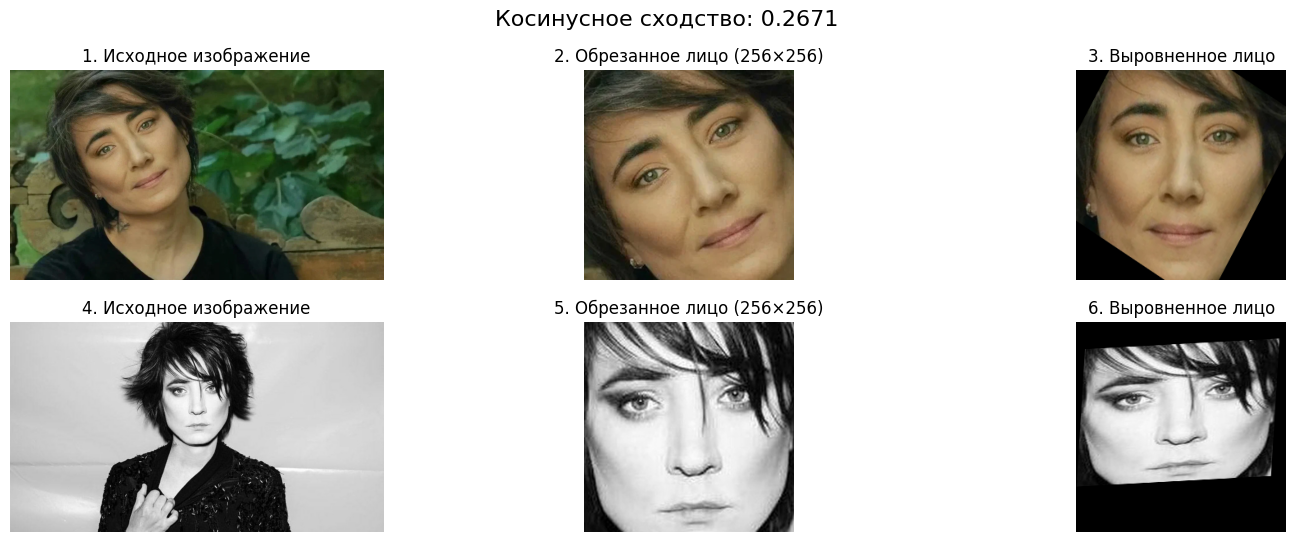

 Лица, вероятно, принадлежат разным людям.


In [48]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Да, с Земфирой прям невезение какое-то:)

Загрузите два изображения для сравнения.


Saving Sadovn-1.jpg to Sadovn-1 (2).jpg
Saving Sadovn-2.webp to Sadovn-2 (2).webp

 Результат:
Косинусное сходство между лицами: 0.5086


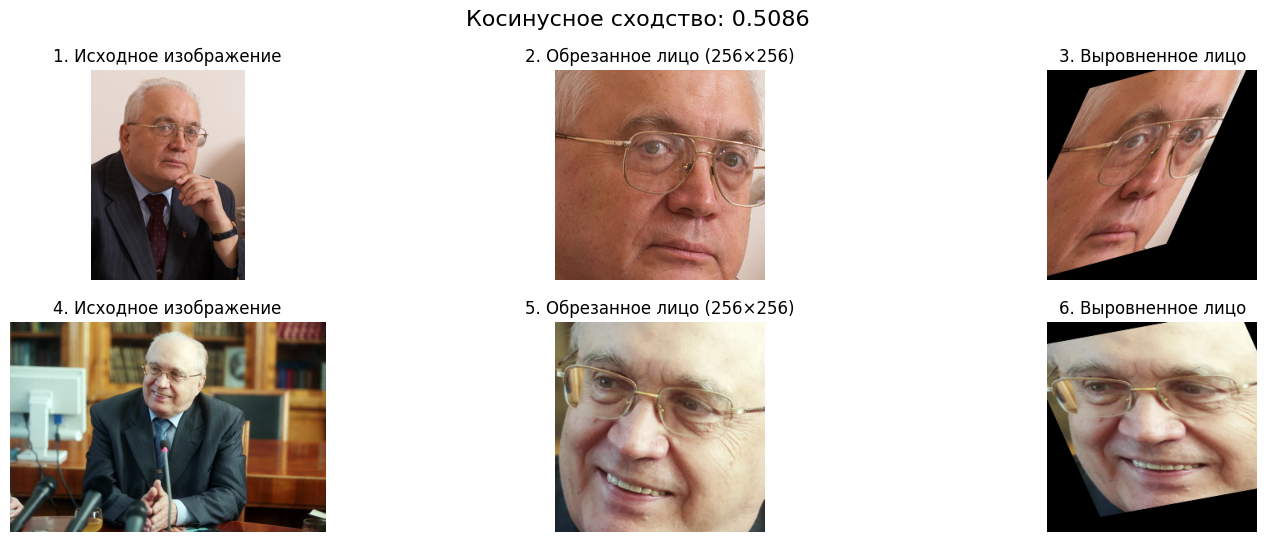

 Неоднозначно: сходство на границе.


In [49]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

Загрузите два изображения для сравнения.


Saving Picture-2.png to Picture-2 (2).png
Saving Queen-3.webp to Queen-3.webp

 Результат:
Косинусное сходство между лицами: 0.1250


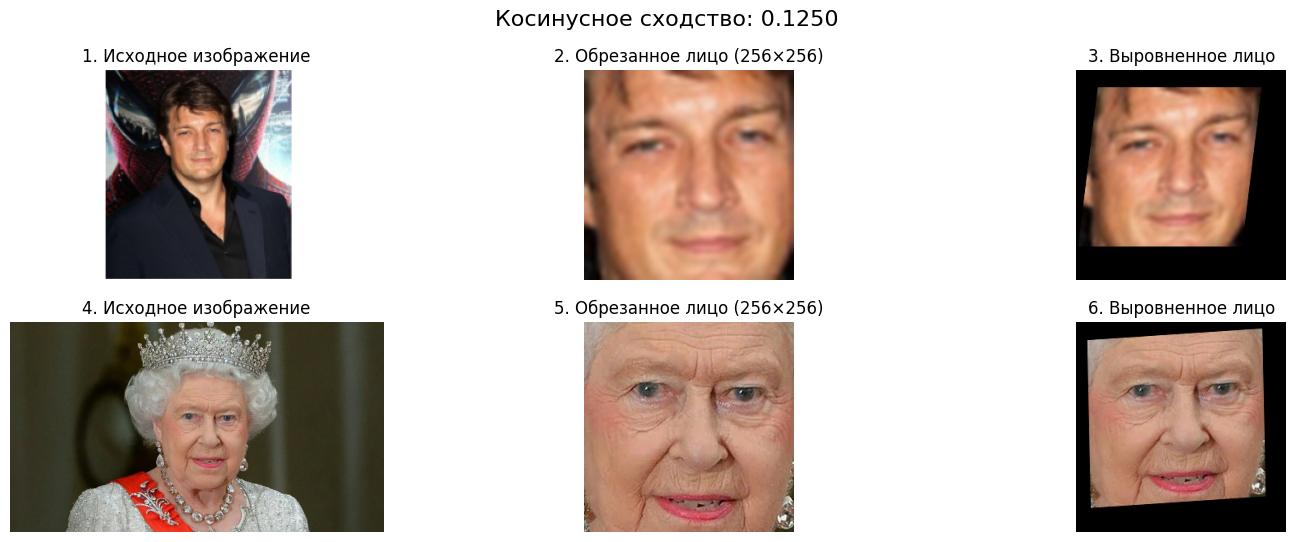

 Лица, вероятно, принадлежат разным людям.


In [50]:
# Запуск системы
if __name__ == "__main__":
    run_comparison2()

В общем, честно сказать, система работает не лучшим образом. Если разных людей она хотя бы отличает, то одного и того же человека узнает с огромным трудом. Или не узнает.

- TODO1: Заметно, что аффинное преобразование, реализованное в моем пайплайне, сильно деформирует лицо. Нужно применить что-то более сложное, для начала попробовать сделать преобразованеи по 5 точкам. Если станет лучше, то в дальнейшем неплохо было бы научить модель предсказывать больше точек, и поповрачивать лица по ним (но это нужен размеченный датасет, а его нет)
- TODO2: Доучить модель распознавания лиц на 30 эпохах, посмотреть, что будет.
- TODO3: Подумать про обучающий датасет, возможно, модели просто не хватило материала для обучения. Увеличить разнообразие ракурсов было бы неплохо. Возможно, также обрезку нужно делать после выравнивания, а не до. То есть, допустим, ключевые точки искать внутри каждого найденного Bbox, но обрезать уже после, ориентируясь на глаза и нос человека, после выравнивания. Это выглядит более логичным, чем обрезка вначале, тк при обрезке до выравнивания остается слишком большая часть щеки, если ракурс профиль, и система начинает видимо путаться.